In [1]:
from google.colab import drive
drive.mount("./content")

Mounted at ./content


In [2]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 85.1 MB/s eta 0:00:00


In [3]:
import matplotlib.pyplot as plt
import koreanize_matplotlib
import pandas as pd
df= pd.read_csv("/content/content/MyDrive/코드잇_DA_13기_이현재/미션 16/bakery_sales_revised.csv")
df.head(10)

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,10/30/2016 9:58,morning,weekend
1,2,Scandinavian,10/30/2016 10:05,morning,weekend
2,2,Scandinavian,10/30/2016 10:05,morning,weekend
3,3,Hot chocolate,10/30/2016 10:07,morning,weekend
4,3,Jam,10/30/2016 10:07,morning,weekend
5,3,Cookies,10/30/2016 10:07,morning,weekend
6,4,Muffin,10/30/2016 10:08,morning,weekend
7,5,Coffee,10/30/2016 10:13,morning,weekend
8,5,Pastry,10/30/2016 10:13,morning,weekend
9,5,Bread,10/30/2016 10:13,morning,weekend


In [4]:
print(df.shape)
df.info()

(20507, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20507 entries, 0 to 20506
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Transaction      20507 non-null  int64 
 1   Item             20507 non-null  object
 2   date_time        20507 non-null  object
 3   period_day       20507 non-null  object
 4   weekday_weekend  20507 non-null  object
dtypes: int64(1), object(4)
memory usage: 801.2+ KB


In [5]:
df['Item'].unique() # 상품

array(['Bread', 'Scandinavian', 'Hot chocolate', 'Jam', 'Cookies',
       'Muffin', 'Coffee', 'Pastry', 'Medialuna', 'Tea', 'Tartine',
       'Basket', 'Mineral water', 'Farm House', 'Fudge', 'Juice',
       "Ella's Kitchen Pouches", 'Victorian Sponge', 'Frittata',
       'Hearty & Seasonal', 'Soup', 'Pick and Mix Bowls', 'Smoothies',
       'Cake', 'Mighty Protein', 'Chicken sand', 'Coke',
       'My-5 Fruit Shoot', 'Focaccia', 'Sandwich', 'Alfajores', 'Eggs',
       'Brownie', 'Dulce de Leche', 'Honey', 'The BART', 'Granola',
       'Fairy Doors', 'Empanadas', 'Keeping It Local', 'Art Tray',
       'Bowl Nic Pitt', 'Bread Pudding', 'Adjustment', 'Truffles',
       'Chimichurri Oil', 'Bacon', 'Spread', 'Kids biscuit', 'Siblings',
       'Caramel bites', 'Jammie Dodgers', 'Tiffin', 'Olum & polenta',
       'Polenta', 'The Nomad', 'Hack the stack', 'Bakewell',
       'Lemon and coconut', 'Toast', 'Scone', 'Crepes', 'Vegan mincepie',
       'Bare Popcorn', 'Muesli', 'Crisps', 'Pintxos', 

In [6]:
df['period_day'].unique() # 시간대구분

array(['morning', 'afternoon', 'evening', 'night'], dtype=object)

In [7]:
df['weekday_weekend'].unique() # 시간대구분

array(['weekend', 'weekday'], dtype=object)

In [8]:
df=df.drop_duplicates() # 중복행 제거
df.shape

(18887, 5)

In [9]:
df.head(10)

,Transaction,Item,date_time,period_day,weekday_weekend
0,1,Bread,10/30/2016 9:58,morning,weekend
1,2,Scandinavian,10/30/2016 10:05,morning,weekend
3,3,Hot chocolate,10/30/2016 10:07,morning,weekend
4,3,Jam,10/30/2016 10:07,morning,weekend
5,3,Cookies,10/30/2016 10:07,morning,weekend
6,4,Muffin,10/30/2016 10:08,morning,weekend
7,5,Coffee,10/30/2016 10:13,morning,weekend
8,5,Pastry,10/30/2016 10:13,morning,weekend
9,5,Bread,10/30/2016 10:13,morning,weekend
10,6,Medialuna,10/30/2016 10:16,morning,weekend


In [10]:
customer_df = df.sort_values('date_time').drop_duplicates(subset=['Transaction'])

weekday_counts = customer_df['weekday_weekend'].value_counts().reindex(['weekday','weekend'])
weekday_counts.index =['주중','주말']
weekday_ratio = weekday_counts / weekday_counts.sum() * 100

weekday_result = pd.DataFrame({
    '구분': weekday_counts.index,
    '고객수': weekday_counts.values,
    '비율(%)': weekday_ratio.round(1).values
})
weekday_result

,구분,고객수,비율(%)
0,주중,6145,64.9
1,주말,3320,35.1


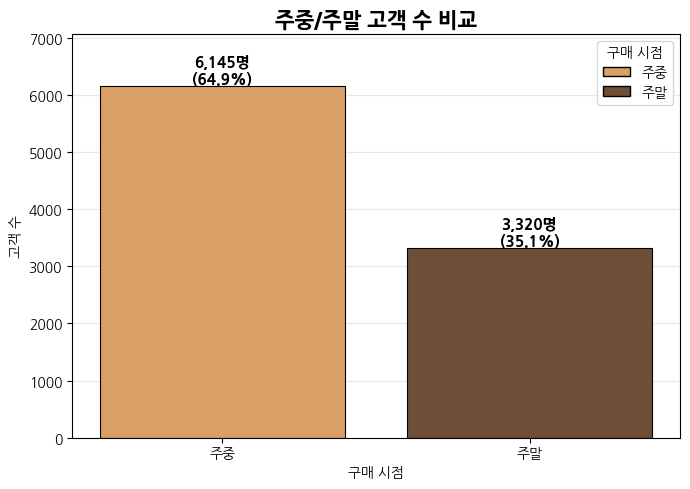

In [11]:
import matplotlib.pyplot as plt
import koreanize_matplotlib
from matplotlib.patches import Patch

fig, ax = plt.subplots(figsize=(7, 5))

# 색상 지정
colors = ["#D9A066", "#6F4E37"]  # 주중: 파랑, 주말: 주황

bars = ax.bar(
    weekday_counts.index,
    weekday_counts.values,
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

ax.set_title("주중/주말 고객 수 비교", fontsize=15, fontweight="bold")
ax.set_xlabel("구매 시점")
ax.set_ylabel("고객 수")  # Transaction 기준

# y축 보조선
ax.grid(axis="y", alpha=0.3)
ax.set_axisbelow(True)

# 막대 위에 값 + 비율 표시
for bar, count, ratio in zip(bars, weekday_counts.values, weekday_ratio.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}명\n({ratio:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

# y축 범위 조정
ax.set_ylim(0, weekday_counts.max() * 1.15)

# 레전드 직접 생성
legend_elements = [
    Patch(facecolor="#D9A066", edgecolor="black", label="주중"),
    Patch(facecolor="#6F4E37", edgecolor="black", label="주말")
]

ax.legend(
    handles=legend_elements,
    title="구매 시점",
    loc="upper right"
)

plt.tight_layout()
plt.show()

In [12]:
period_counts = customer_df['period_day'].value_counts().reindex(["morning", "afternoon", "evening", "night"])
period_counts.index = ['아침','오후','저녁','밤']
period_ratio = period_counts / period_counts.sum() * 100

period_result = pd.DataFrame({
    '시간대': period_counts.index,
    '고객수': period_counts.values,
    '비율(%)': period_ratio.round(1).values
})
period_result

,시간대,고객수,비율(%)
0,아침,4103,43.3
1,오후,5089,53.8
2,저녁,261,2.8
3,밤,12,0.1


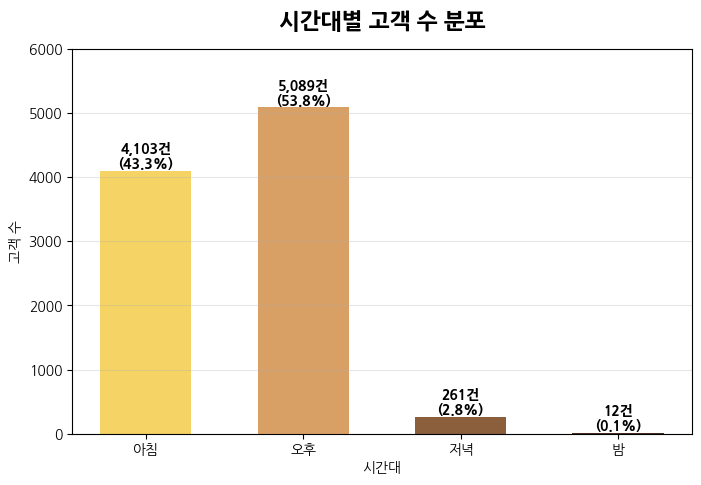

In [13]:
fig, ax = plt.subplots(figsize=(8,5))
colors =["#F6D365", "#D9A066", "#8B5E3C", "#4B2E1E"]
bars = ax.bar(period_counts.index, period_counts.values,color=colors, width=0.58)

ax.set_title("시간대별 고객 수 분포", fontsize= 16, fontweight='bold', pad=15)
ax.set_xlabel("시간대")
ax.set_ylabel("고객 수")
ax.grid(axis='y', alpha=0.3)

for bar, count, ratio in zip(bars, period_counts.values, period_ratio.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}건\n({ratio:.1f}%)",
        ha='center',
        va='bottom',
        fontweight='bold'
    )
ax.set_ylim(0,period_counts.max()* 1.18)
plt.show()

In [14]:
item_counts = df.groupby("Item")["Transaction"].nunique().sort_values(ascending=False)
top_items = item_counts.head(12)

top_item_result = top_items.reset_index()
top_item_result.columns = ["상품", "포함 거래 수"]
top_item_result

,상품,포함 거래 수
0,Coffee,4528
1,Bread,3097
2,Tea,1350
3,Cake,983
4,Pastry,815
5,Sandwich,680
6,Medialuna,585
7,Hot chocolate,552
8,Cookies,515
9,Brownie,379


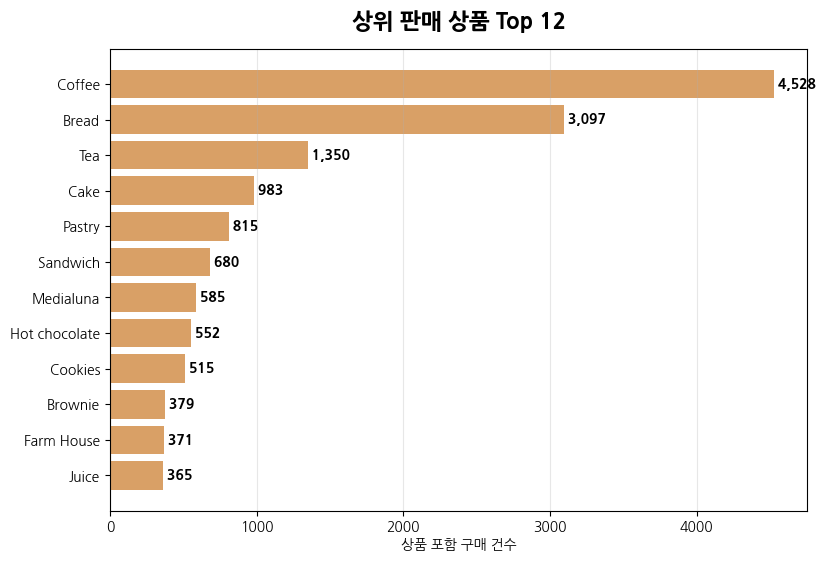

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))
plot_data = top_items.sort_values(ascending=True)
ax.barh(plot_data.index, plot_data.values, color="#D9A066")

ax.set_title("상위 판매 상품 Top 12", fontsize=16, fontweight="bold", pad=15)
ax.set_xlabel("상품 포함 구매 건수") # transaction 기준
ax.grid(axis="x", alpha=0.3)

for i, value in enumerate(plot_data.values):
    ax.text(value, i, f" {value:,}", va="center", fontweight="bold")

plt.show()


## 4. 장바구니 분석 설계

앞선 시각화에서는 고객의 구매 시점과 주요 상품 분포를 확인했다. 이제 `Transaction`을 하나의 장바구니로 보고, 같은 구매 안에서 함께 등장한 상품 조합을 분석한다.

이번 분석에는 연관규칙 분석(Association Rule Mining)을 사용한다. 연관규칙 분석은 고객이 특정 상품을 구매했을 때 다른 상품도 함께 구매할 가능성이 높은지 확인하는 방법이다. 대표적으로 **Apriori 알고리즘**의 개념을 활용한다.

### 사용 알고리즘: Apriori 기반 연관규칙 분석

Apriori 알고리즘은 다음 원리를 기반으로 한다.

- 자주 함께 등장하는 상품 조합을 먼저 찾는다.
- 자주 등장하지 않는 조합은 더 큰 조합으로 확장하지 않는다.
- 발견된 상품 조합을 바탕으로 `A 상품을 산 고객이 B 상품도 살 가능성`을 규칙 형태로 만든다.

### 주요 평가 지표

- **Support(지지도)**  
  전체 거래 중 해당 상품 조합이 함께 등장한 비율이다. 너무 낮으면 실제 마케팅에 활용하기 어렵다.

- **Confidence(신뢰도)**  
  A 상품을 산 거래 중 B 상품도 함께 산 비율이다. 조건부 확률에 가깝다.

- **Lift(향상도)**  
  A와 B가 우연히 같이 팔린 정도보다 얼마나 더 강하게 연결되어 있는지를 보여준다.  
  `Lift > 1`이면 두 상품은 독립적인 관계보다 함께 구매될 가능성이 높다고 해석한다.

### 분석 방향

- `Transaction` 기준으로 상품들을 리스트화한다.
- 같은 거래 안에서 중복된 동일 상품은 한 번만 계산한다.
- 연관성이 높은 규칙은 **Lift 기준 Top 10**으로 시각화한다.
- 나머지 결과는 표로 확인한다.


In [16]:
from itertools import combinations
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import koreanize_matplotlib

# 원본 df를 보호하기 위해 복사본 생성
basket_base = df.copy()

# 날짜 컬럼이 문자열이면 datetime으로 변환
basket_base['date_time'] = pd.to_datetime(basket_base['date_time'], errors='coerce')

# 장바구니 생성: Transaction별 구매 상품 리스트
basket_df = (
    basket_base
    .groupby('Transaction')['Item']
    .apply(lambda x: sorted(set(x.dropna())))
    .reset_index(name='basket')
)

# 장바구니 크기 계산
basket_df['basket_size'] = basket_df['basket'].apply(len)

basket_df.head()


,Transaction,basket,basket_size
0,1,[Bread],1
1,2,[Scandinavian],1
2,3,"[Cookies, Hot chocolate, Jam]",3
3,4,[Muffin],1
4,5,"[Bread, Coffee, Pastry]",3


In [17]:
basket_summary = pd.DataFrame({
    '분석 항목': [
        '전체 거래 수',
        '상품 종류 수',
        '평균 장바구니 크기',
        '2개 이상 상품 구매 거래 수',
        '2개 이상 상품 구매 비율(%)'
    ],
    '값': [
        len(basket_df),
        basket_base['Item'].nunique(),
        round(basket_df['basket_size'].mean(), 2),
        int((basket_df['basket_size'] >= 2).sum()),
        round((basket_df['basket_size'] >= 2).mean() * 100, 1)
    ]
})

basket_summary

,분석 항목,값
0,전체 거래 수,9465.0
1,상품 종류 수,94.0
2,평균 장바구니 크기,2.0
3,2개 이상 상품 구매 거래 수,5517.0
4,2개 이상 상품 구매 비율(%),58.3


In [18]:
# 상품별 포함 거래 수 Top 10
top_item_table = (
    basket_base
    .groupby('Item')['Transaction']
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

top_item_table.columns = ['상품', '포함 거래 수']
top_item_table

,상품,포함 거래 수
0,Coffee,4528
1,Bread,3097
2,Tea,1350
3,Cake,983
4,Pastry,815
5,Sandwich,680
6,Medialuna,585
7,Hot chocolate,552
8,Cookies,515
9,Brownie,379


In [19]:
# 연관규칙 분석을 위한 지표 계산
# support, confidence, lift를 직접 계산
transaction_count = len(basket_df)

item_counter = Counter()
pair_counter = Counter()

for basket in basket_df['basket']:
    # 개별 상품 등장 거래 수
    item_counter.update(basket)

    # 2개 상품 조합 등장 거래 수
    pair_counter.update(combinations(sorted(basket), 2))

rules = []

for (item_a, item_b), pair_count in pair_counter.items():
    support = pair_count / transaction_count

    # A -> B
    confidence_a_to_b = pair_count / item_counter[item_a]
    lift_a_to_b = confidence_a_to_b / (item_counter[item_b] / transaction_count)

    rules.append({
        'antecedent': item_a,
        'consequent': item_b,
        'support': support,
        'confidence': confidence_a_to_b,
        'lift': lift_a_to_b,
        'pair_count': pair_count,
        'antecedent_count': item_counter[item_a],
        'consequent_count': item_counter[item_b]
    })

    # B -> A
    confidence_b_to_a = pair_count / item_counter[item_b]
    lift_b_to_a = confidence_b_to_a / (item_counter[item_a] / transaction_count)

    rules.append({
        'antecedent': item_b,
        'consequent': item_a,
        'support': support,
        'confidence': confidence_b_to_a,
        'lift': lift_b_to_a,
        'pair_count': pair_count,
        'antecedent_count': item_counter[item_b],
        'consequent_count': item_counter[item_a]
    })

rules_df = pd.DataFrame(rules)

# 너무 드문 조합은 제외한다.
# 보고서 해석 안정성을 위해 최소 지지도, 최소 신뢰도, 최소 동시 구매 건수를 둔다.
min_support = 0.005      # 전체 거래의 0.5% 이상
min_confidence = 0.10    # 조건부 구매 확률 10% 이상
min_pair_count = 30      # 최소 30건 이상 함께 등장

filtered_rules = rules_df[
    (rules_df['support'] >= min_support) &
    (rules_df['confidence'] >= min_confidence) &
    (rules_df['pair_count'] >= min_pair_count)
].copy()

filtered_rules = filtered_rules.sort_values(
    by=['lift', 'confidence', 'support'],
    ascending=False
)

filtered_rules.head(10)


,antecedent,consequent,support,confidence,lift,pair_count,antecedent_count,consequent_count
518,Coke,Sandwich,0.005177,0.266304,3.706722,49,184,680
117,Juice,Cookies,0.006128,0.158904,2.920442,58,365,515
116,Cookies,Juice,0.006128,0.112621,2.920442,58,515,365
257,Soup,Sandwich,0.005494,0.159509,2.220227,52,326,680
424,Juice,Sandwich,0.005811,0.150685,2.097401,55,365,680
1,Hot chocolate,Cookies,0.006022,0.103261,1.897794,57,552,515
0,Cookies,Hot chocolate,0.006022,0.110680,1.897794,57,515,552
273,Hot chocolate,Cake,0.011410,0.195652,1.883874,108,552,983
272,Cake,Hot chocolate,0.011410,0.109868,1.883874,108,983,552
108,Soup,Tea,0.009086,0.263804,1.849557,86,326,1350


In [21]:
# 연관성이 높은 규칙 Top 10
# Lift 기준으로 정렬

top10_rules = filtered_rules.head(10).copy()

top10_rules['규칙'] = top10_rules['antecedent'] + ' → ' + top10_rules['consequent']

top10_rules_table = top10_rules[[
    '규칙', 'pair_count', 'support', 'confidence', 'lift'
]].copy()

top10_rules_table.columns = ['연관규칙', '동시 구매 건수', '지지도', '신뢰도', '향상도']

top10_rules_table['지지도'] = (top10_rules_table['지지도'] * 100).round(2)
top10_rules_table['신뢰도'] = (top10_rules_table['신뢰도'] * 100).round(1)
top10_rules_table['향상도'] = top10_rules_table['향상도'].round(2)

top10_rules_table


,연관규칙,동시 구매 건수,지지도,신뢰도,향상도
518,Coke → Sandwich,49,0.52,26.6,3.71
117,Juice → Cookies,58,0.61,15.9,2.92
116,Cookies → Juice,58,0.61,11.3,2.92
257,Soup → Sandwich,52,0.55,16.0,2.22
424,Juice → Sandwich,55,0.58,15.1,2.10
1,Hot chocolate → Cookies,57,0.60,10.3,1.90
0,Cookies → Hot chocolate,57,0.60,11.1,1.90
273,Hot chocolate → Cake,108,1.14,19.6,1.88
272,Cake → Hot chocolate,108,1.14,11.0,1.88
108,Soup → Tea,86,0.91,26.4,1.85


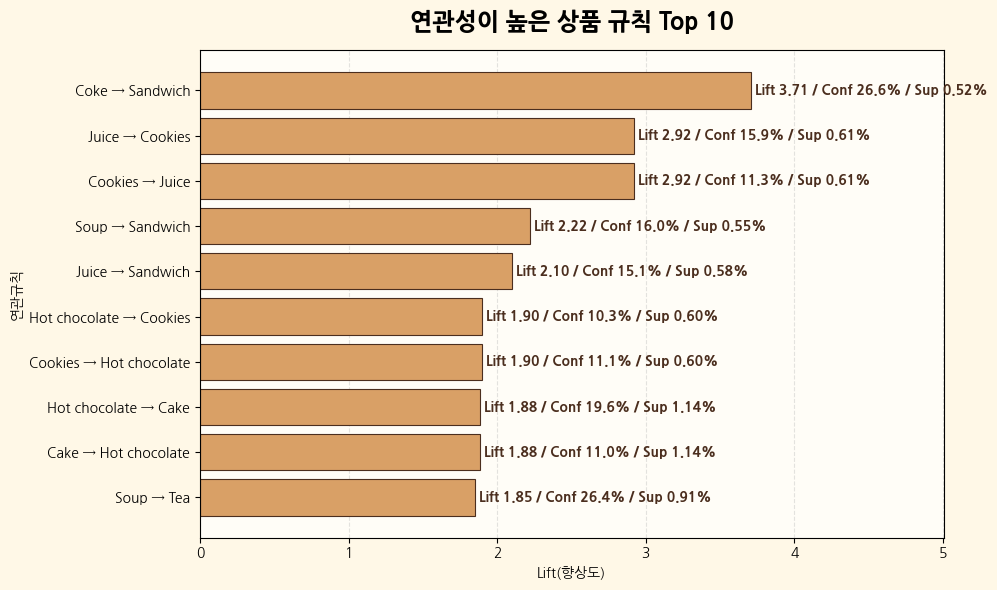

In [23]:
# 연관규칙 Top 10 시각화
plot_rules = top10_rules.sort_values('lift', ascending=True).copy()

fig, ax = plt.subplots(figsize=(10, 6))

bakery_color = '#D9A066'
edge_color = '#4B2E1E'
background_color = '#FFF8E7'

bars = ax.barh(
    plot_rules['규칙'],
    plot_rules['lift'],
    color=bakery_color,
    edgecolor=edge_color,
    linewidth=0.8
)

ax.set_title('연관성이 높은 상품 규칙 Top 10', fontsize=17, fontweight='bold', pad=15)
ax.set_xlabel('Lift(향상도)')
ax.set_ylabel('연관규칙')

ax.grid(axis='x', linestyle='--', alpha=0.35)
ax.set_axisbelow(True)

fig.patch.set_facecolor(background_color)
ax.set_facecolor('#FFFDF7')

for bar, lift, conf, sup in zip(
    bars,
    plot_rules['lift'],
    plot_rules['confidence'],
    plot_rules['support']
):
    ax.text(
        bar.get_width() + 0.03,
        bar.get_y() + bar.get_height() / 2,
        f'Lift {lift:.2f} / Conf {conf*100:.1f}% / Sup {sup*100:.2f}%',
        va='center',
        fontsize=10,
        color=edge_color,
        fontweight='bold'
    )

ax.set_xlim(0, plot_rules['lift'].max() * 1.35)

plt.tight_layout()
plt.show()


In [24]:
# 동시 구매 건수가 많은 상품 조합 Top 10
pair_rows = []

for (item_a, item_b), pair_count in pair_counter.items():
    pair_support = pair_count / transaction_count
    lift = pair_support / ((item_counter[item_a] / transaction_count) * (item_counter[item_b] / transaction_count))

    pair_rows.append({
        '상품 1': item_a,
        '상품 2': item_b,
        '동시 구매 건수': pair_count,
        '지지도(%)': round(pair_support * 100, 2),
        '향상도': round(lift, 2)
    })

pair_table = pd.DataFrame(pair_rows)

pair_table.sort_values('동시 구매 건수', ascending=False).head(10)

,상품 1,상품 2,동시 구매 건수,지지도(%),향상도
3,Bread,Coffee,852,9.00,0.58
84,Cake,Coffee,518,5.47,1.10
10,Coffee,Tea,472,4.99,0.73
5,Coffee,Pastry,450,4.75,1.15
130,Coffee,Sandwich,362,3.82,1.11
9,Coffee,Medialuna,333,3.52,1.19
36,Coffee,Hot chocolate,280,2.96,1.06
4,Bread,Pastry,276,2.92,1.03
57,Coffee,Cookies,267,2.82,1.08
30,Bread,Tea,266,2.81,0.60



## 5. 장바구니 분석 결과 해석

연관규칙 분석에서는 단순히 많이 팔린 상품 조합만 보는 것이 아니라, **두 상품이 우연보다 얼마나 강하게 함께 구매되는지**를 확인하는 것이 중요하다. 따라서 시각화는 `Lift(향상도)` 기준 Top 10 규칙으로 구성했다.

해석 기준은 다음과 같다.

- `Lift > 1`이면 두 상품은 독립적인 관계보다 함께 구매될 가능성이 높다.
- `Confidence`가 높을수록 선행 상품 구매자가 후행 상품도 함께 구매할 가능성이 높다.
- `Support`가 너무 낮으면 실제 마케팅 전략으로 활용하기 어렵다.
- 따라서 `Lift`, `Confidence`, `Support`를 함께 고려해야 한다.

### 인사이트 작성 방향

- Lift가 높은 조합은 **세트 메뉴 구성** 또는 **교차 판매 추천**에 활용할 수 있다.
- 동시 구매 건수가 많은 조합은 이미 고객에게 익숙한 조합이므로 **매장 진열/묶음 판매**에 적합하다.
- Lift는 높지만 동시 구매 건수가 낮은 조합은 테스트용 프로모션으로 먼저 검증하는 것이 적절하다.

### 보고서용 요약 문장

본 분석에서는 `Transaction`을 하나의 장바구니로 정의하고, 상품 간 동시 구매 관계를 연관규칙 분석으로 확인하였다. 특히 Lift 기준 상위 규칙을 시각화하여 단순 판매량이 아닌 상품 간 결합 강도를 파악하였다. 분석 결과는 베이커리 매장의 세트 메뉴 구성, 상품 진열 전략, 시간대별 추천 상품 기획에 활용될 수 있다.
